In [2]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

In [3]:
def open_close(img,struk):
    return cv2.morphologyEx(cv2.morphologyEx(img,cv2.MORPH_OPEN,struk),cv2.MORPH_CLOSE,struk)

def close_open(img,struk):
    return cv2.morphologyEx(cv2.morphologyEx(img,cv2.MORPH_CLOSE,struk),cv2.MORPH_OPEN,struk)

<Figure size 432x288 with 0 Axes>

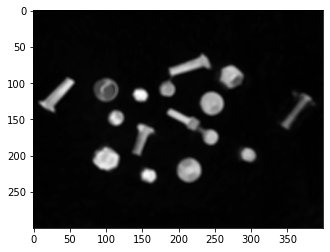

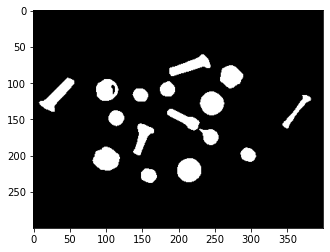

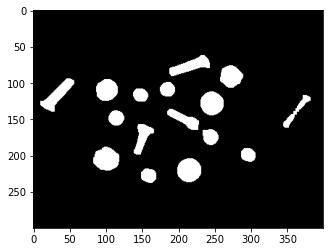

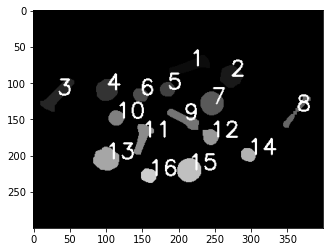

In [4]:
n=cv2.imread('details.png',cv2.IMREAD_GRAYSCALE)
plt.gray()
mat=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(13,13))
tophat=cv2.morphologyEx(n,cv2.MORPH_TOPHAT,mat)
bhat=cv2.morphologyEx(n,cv2.MORPH_BLACKHAT,mat)
hutt=tophat+bhat
hutt=cv2.GaussianBlur(hutt,(5,5), 5)
plt.figure()
plt.imshow(hutt)
hutt=hutt.astype('uint8')
hutt=np.where(hutt>46,1,0)
hutt=hutt.astype('uint8')
plt.figure()
plt.imshow(hutt)

n=5
mat=np.ones((n,n))
hutt=close_open(hutt,mat)
hutt=close_open(hutt,mat)
hutt=close_open(hutt,mat)
hutt=close_open(hutt,mat)

plt.figure()
plt.imshow(hutt)
plt.figure()
label,obind,stats,ob=cv2.connectedComponentsWithStats(hutt)
ccl_vis = obind.copy()
s=0
for i in range(2,label+1):
    cv2.putText(ccl_vis,str(i-1),(int(ob[i-1,0]),int(ob[i-1,1])),cv2.FONT_HERSHEY_SIMPLEX,1,(20,0,0),2)
plt.imshow(ccl_vis)


0.36914897391595075
0.16048312654666907
0.3374371457521853
0.1596120352178642
0.1593492762079248
0.16118751870184844
0.15926934906937307
0.7489363489168874
0.3427903052491145
0.15921232296616553
0.29499291073015077
0.16237539333628725
0.1610492200293319
0.16109693985064694
0.15919807342250875
0.16085399961833263


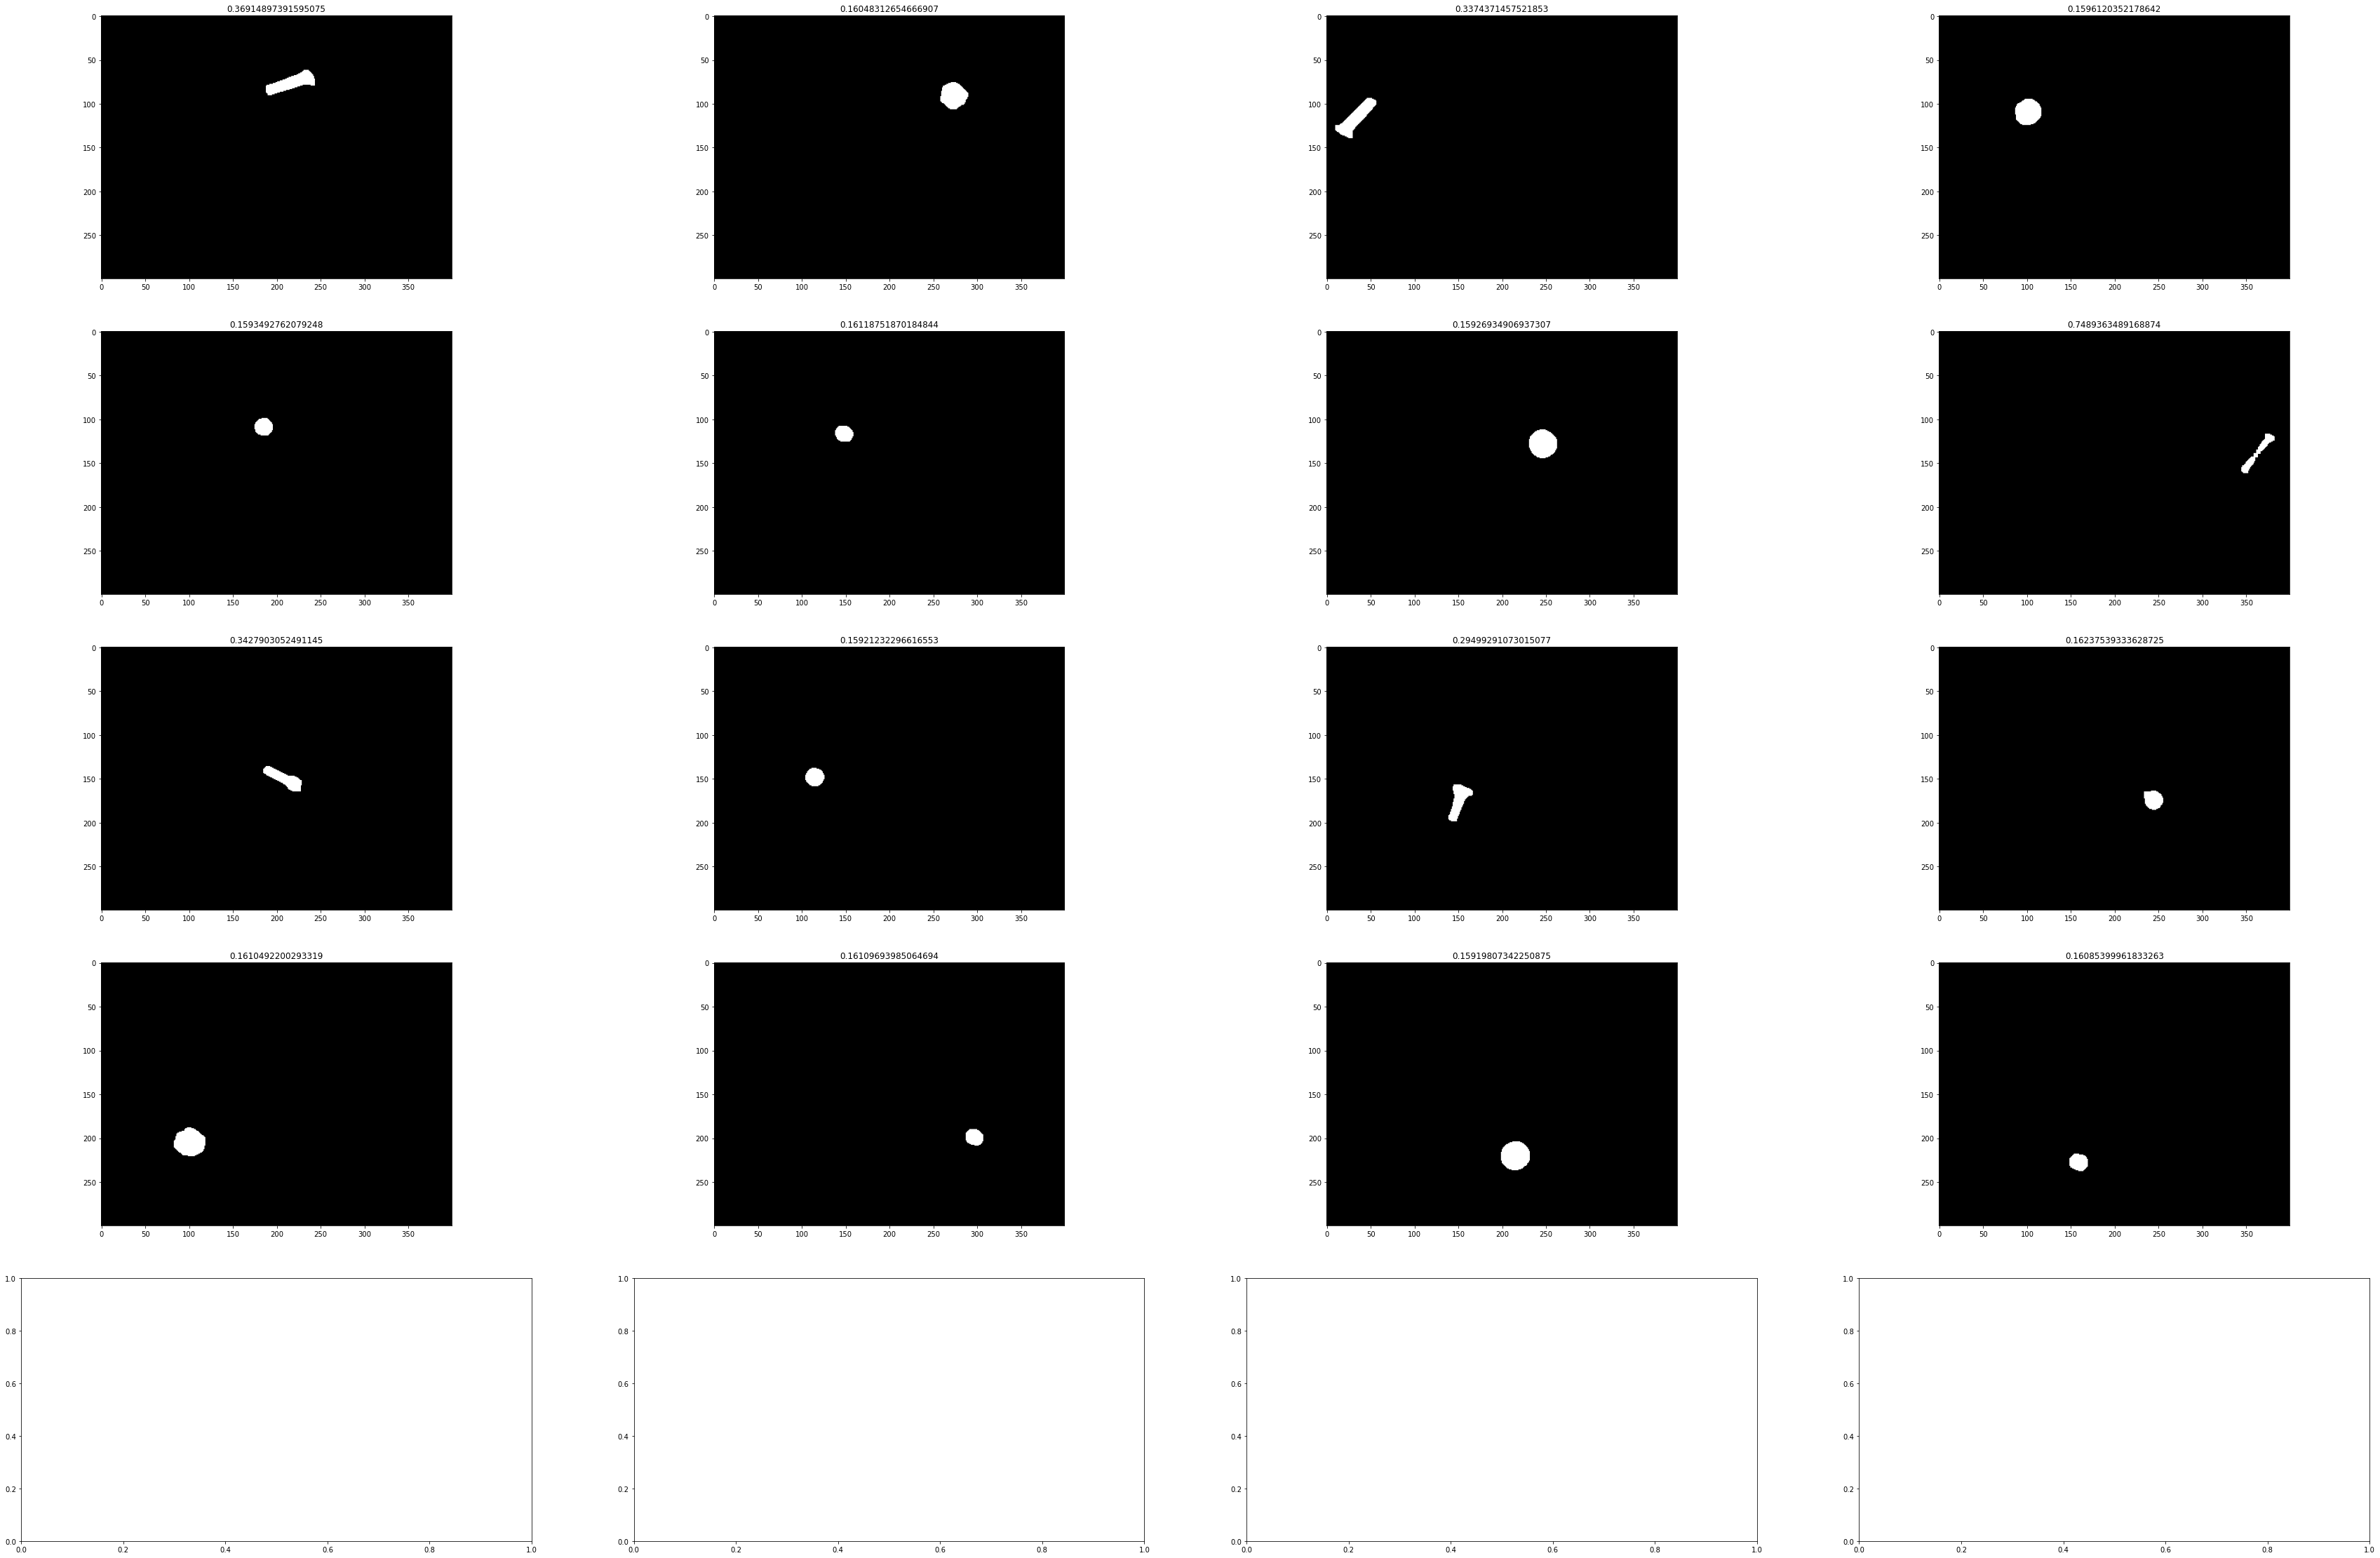

In [5]:
fig,ax=plt.subplots(int(label/4)+1,4,figsize=(60,40))
mom=[]
hmom=[]
im=[]
for i in range(1,label):
    ob=(obind==i)*1
    ob=ob.astype('uint8')
    im.append(ob)
    ax[int(np.floor((i-1)/4))][(i-1)%4].imshow(ob)
    mom.append(cv2.moments(ob))
    hmom.append(cv2.HuMoments(mom[i-1]))
    ax[int(np.floor((i-1)/4))][(i-1)%4].set_title(hmom[-1][0][0])
for i in hmom:
    print(i[0][0])

In [6]:
print(hmom[1][0][0],hmom[5][0][0],hmom[12][0][0],hmom[13][0][0],hmom[15][0][0])
print(hmom[3][0][0],hmom[4][0][0],hmom[6][0][0],hmom[9][0][0],hmom[11][0][0],hmom[14][0][0])

0.16048312654666907 0.16118751870184844 0.1610492200293319 0.16109693985064694 0.16085399961833263
0.1596120352178642 0.1593492762079248 0.15926934906937307 0.15921232296616553 0.16237539333628725 0.15919807342250875


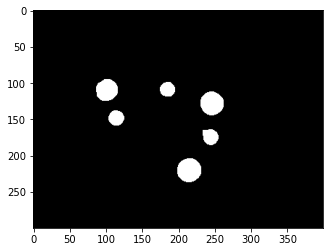

In [7]:
new=np.zeros((hutt.shape))
for i in range(label-1):
    if( 0.13<hmom[i][0][0] < 0.16 or 0.162<hmom[i][0][0] < 0.29):
        new+=im[i]
plt.figure()
plt.imshow(new)

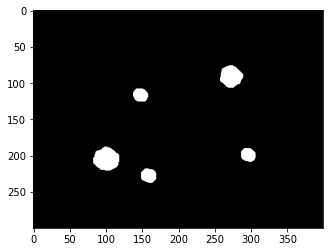

In [8]:
new=np.zeros((hutt.shape))
for i in range(label-1):
    if( 0.16<hmom[i][0][0] < 0.1615):
        new+=im[i]
plt.figure()
plt.imshow(new)

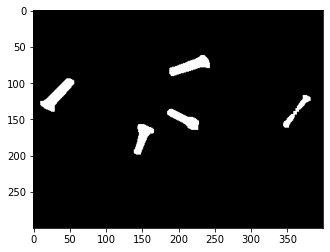

In [9]:
new=np.zeros((hutt.shape))
for i in range(label-1):
    if( hmom[i][0][0] > 0.29):
        new+=im[i]
plt.figure()
plt.imshow(new)